elo

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/clean_results.csv")
df["date"] = pd.to_datetime(df["date"])

In [2]:
df = df.sort_values("date")

In [3]:
elo_ratings = {}
INITIAL_ELO = 1500

In [4]:
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

In [5]:
def actual_scores(home_score, away_score):

    if home_score > away_score:
        return 1, 0

    elif home_score < away_score:
        return 0, 1

    else:
        return 0.5, 0.5

In [6]:
K = 30

for _, row in df.iterrows():

    home = row["home_team"]
    away = row["away_team"]

    if home not in elo_ratings:
        elo_ratings[home] = 1500

    if away not in elo_ratings:
        elo_ratings[away] = 1500

    home_rating = elo_ratings[home]
    away_rating = elo_ratings[away]

    expected_home = expected_score(
        home_rating,
        away_rating
    )

    expected_away = expected_score(
        away_rating,
        home_rating
    )

    actual_home, actual_away = actual_scores(
        row["home_score"],
        row["away_score"]
    )

    elo_ratings[home] += K * (
        actual_home - expected_home
    )

    elo_ratings[away] += K * (
        actual_away - expected_away
    )

In [7]:
elo_df = pd.DataFrame(elo_ratings.items(),columns=["team", "elo"])

In [8]:
elo_df = elo_df.sort_values("elo",ascending=False)

In [9]:
elo_df.head(20)

,team,elo
51,Argentina,1929.841599
119,Spain,1916.631035
118,France,1870.859892
157,Morocco,1865.502871
69,Brazil,1849.167167
15,Japan,1845.263331
70,Portugal,1840.074582
110,Germany,1830.925173
142,Colombia,1829.447379
106,England,1827.459032


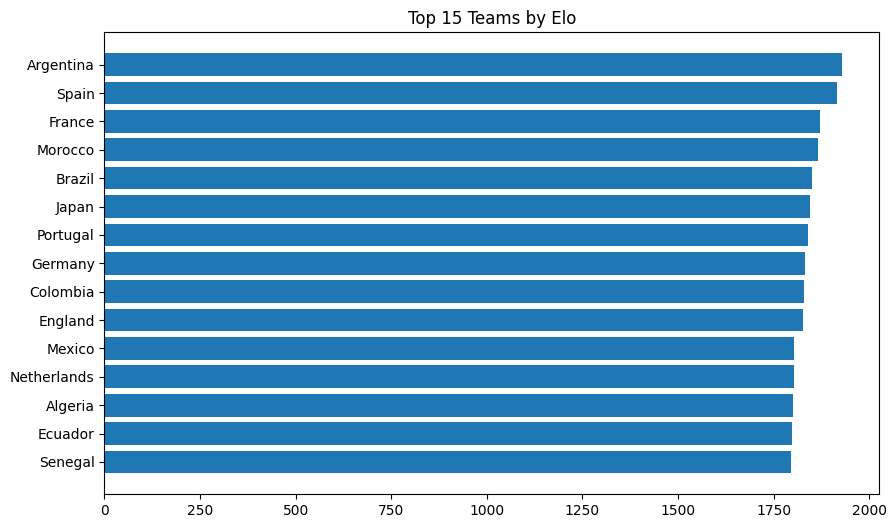

In [10]:
import matplotlib.pyplot as plt

top15 = elo_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15["team"],
    top15["elo"])

plt.gca().invert_yaxis()

plt.title("Top 15 Teams by Elo")

plt.show()

In [11]:
elo_df.to_csv("../data/team_elo_ratings.csv",index=False)